# EnergiAI — Notebook de Ciencia de Datos

**Hackathon ONE G9-LATAM | Alura + Oracle + NoCountry**
**Equipo Team15**

Este notebook documenta el proceso completo de ciencia de datos del proyecto EnergiAI:

1. Exploración y limpieza de datos (EDA)
2. Análisis de patrones de consumo
3. Procesamiento y transformación de variables
4. Entrenamiento de un modelo supervisado (RandomForest)
5. Evaluación con métricas
6. Generación de recomendaciones basadas en reglas
7. Serialización del modelo entrenado
8. (Extra) Detección de anomalías con IsolationForest

El pipeline de entrenamiento reproducible en producción vive en `ml-service/train.py`;
este notebook reutiliza la misma metodología, añadiendo la exploración y el análisis
que no caben en un script de producción.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print(f"scikit-learn {sklearn.__version__} | pandas {pd.__version__}")


scikit-learn 1.5.2 | pandas 2.2.3


## 1. Carga del dataset

El dataset (`dataset_hibrido_v3.csv`) combina consumo real medido (GoiEner Smart Meter
Dataset v7, España) con metodología de calibración validada sobre demanda real de XM
Colombia. Detalle completo de la construcción del dataset en
`docs/data-engineering/INFORME_HIBRIDO_v3.md`.


In [2]:
REPO_ROOT = Path.cwd().resolve().parents[1] if (Path.cwd() / "..").exists() else Path.cwd()
DATA_PATH = REPO_ROOT / "data" / "processed" / "dataset_hibrido_v3.csv"

df = pd.read_csv(DATA_PATH)
print(f"Filas: {len(df):,} | Columnas: {list(df.columns)}")
df.head()


Filas: 50,869 | Columnas: ['consumo_kwh', 'uso_horario_pico', 'cantidad_equipos', 'tipo_inmueble', 'horas_alto_consumo', 'categoria']


,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,categoria
0,325.6,True,17,Casa,9,Moderado
1,590.8,False,17,Casa,119,Eficiente
2,18.8,True,17,Casa,0,Eficiente
3,7.2,False,17,Casa,0,Eficiente
4,45.1,True,17,Casa,1,Eficiente


## 2. Exploración y limpieza de datos (EDA)

### 2.1 Calidad de los datos


In [3]:
print("Nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")
print(f"\nTipos de dato:")
print(df.dtypes)


Nulos por columna:
consumo_kwh           0
uso_horario_pico      0
cantidad_equipos      0
tipo_inmueble         0
horas_alto_consumo    0
categoria             0
dtype: int64

Filas duplicadas: 0

Tipos de dato:
consumo_kwh           float64
uso_horario_pico         bool
cantidad_equipos        int64
tipo_inmueble          object
horas_alto_consumo      int64
categoria              object
dtype: object


### 2.2 Estadísticos descriptivos de las variables numéricas

In [4]:
df.describe(percentiles=[.25, .5, .75, .9]).T


,count,mean,std,min,25%,50%,75%,90%,max
consumo_kwh,50869.0,205.225717,245.121542,0.0,81.5,138.4,231.4,406.42,1997.5
cantidad_equipos,50869.0,10.234976,4.441281,2.0,6.0,10.0,14.0,16.00,21.0
horas_alto_consumo,50869.0,181.777566,115.736950,0.0,115.0,173.0,228.0,304.00,1384.0


### 2.3 Distribución de la variable objetivo (`categoria`)

Confirma que las 3 clases están razonablemente balanceadas (no hay una clase
dominante que sesgue trivialmente al modelo).


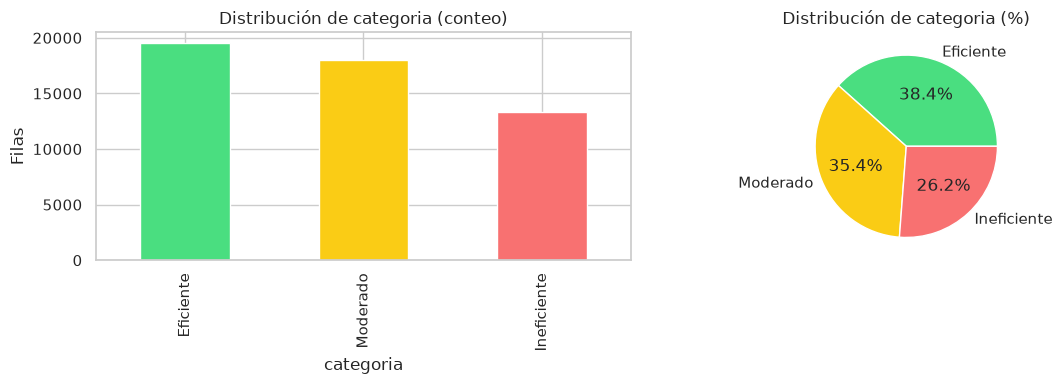

categoria
Eficiente      19519
Moderado       18022
Ineficiente    13328
Name: count, dtype: int64

Baseline de clase mayoritaria: 38.4%


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

counts = df["categoria"].value_counts()
counts.plot(kind="bar", ax=ax[0], color=["#4ade80", "#facc15", "#f87171"])
ax[0].set_title("Distribución de categoria (conteo)")
ax[0].set_ylabel("Filas")

counts.plot(kind="pie", ax=ax[1], autopct="%1.1f%%", colors=["#4ade80", "#facc15", "#f87171"])
ax[1].set_title("Distribución de categoria (%)")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(counts)
print(f"\nBaseline de clase mayoritaria: {counts.max() / len(df):.1%}")


### 2.4 Distribución de las variables predictoras

`consumo_kwh` y `horas_alto_consumo` muestran asimetría hacia la derecha (colas largas
de consumos altos), típico de datos de consumo eléctrico real.


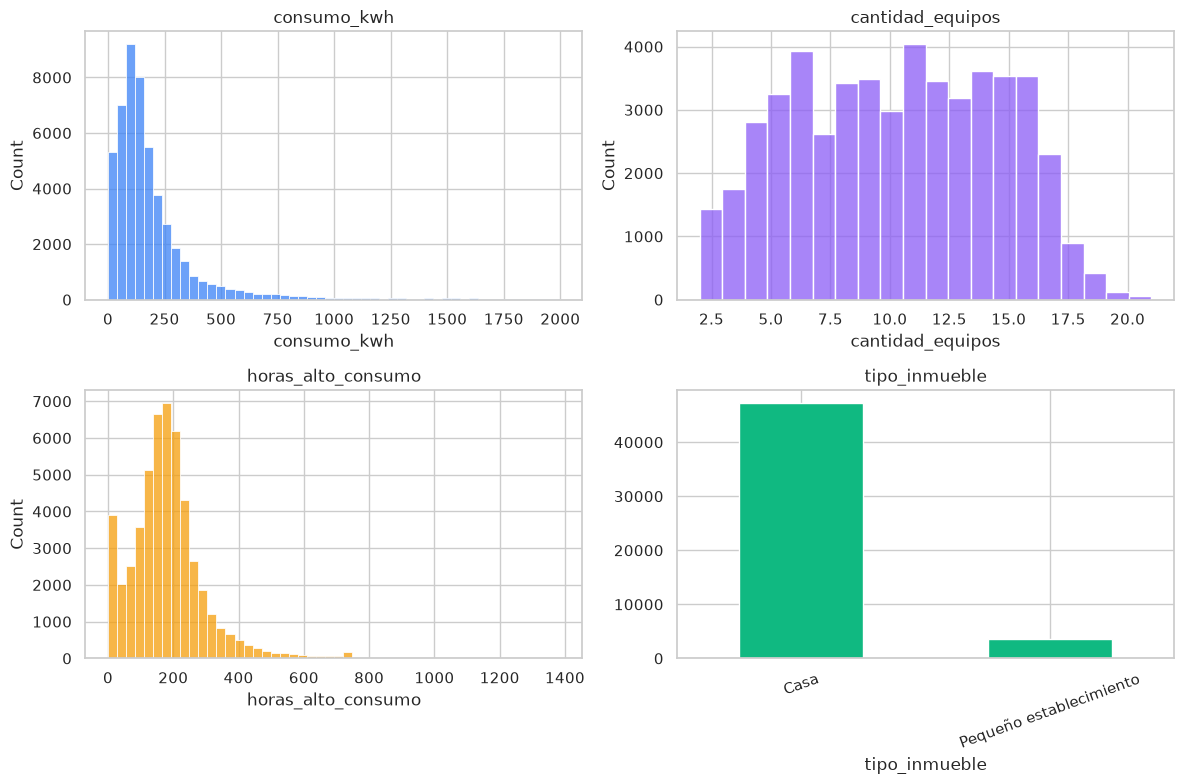

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["consumo_kwh"], bins=50, ax=axes[0, 0], color="#3b82f6")
axes[0, 0].set_title("consumo_kwh")

sns.histplot(df["cantidad_equipos"], bins=20, ax=axes[0, 1], color="#8b5cf6")
axes[0, 1].set_title("cantidad_equipos")

sns.histplot(df["horas_alto_consumo"], bins=50, ax=axes[1, 0], color="#f59e0b")
axes[1, 0].set_title("horas_alto_consumo")

df["tipo_inmueble"].value_counts().plot(kind="bar", ax=axes[1, 1], color="#10b981")
axes[1, 1].set_title("tipo_inmueble")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### 2.5 Relación entre consumo y categoría

Como es esperable, `consumo_kwh` es el factor más discriminante: los perfiles
"Ineficiente" concentran los consumos más altos.


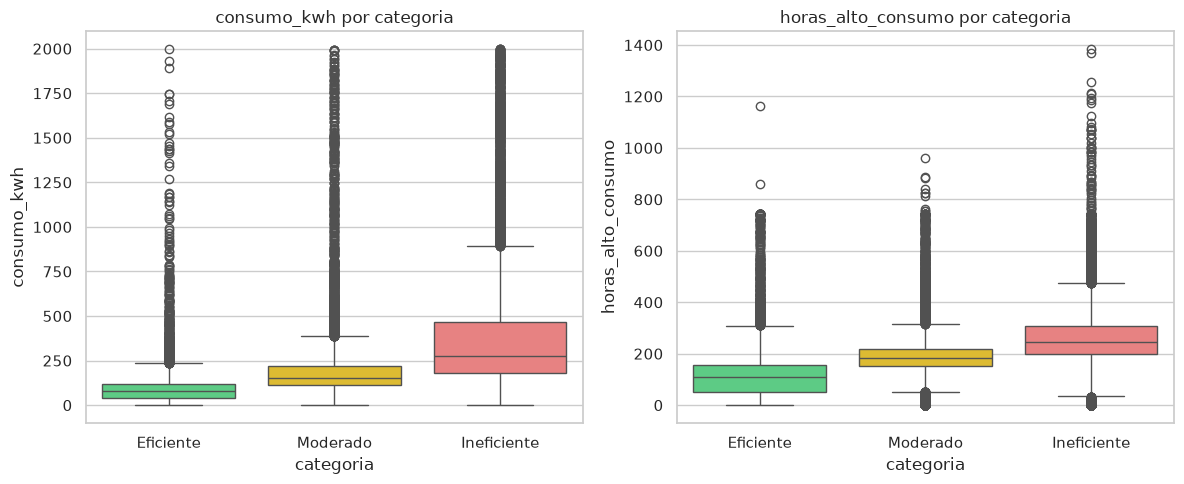

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

order = ["Eficiente", "Moderado", "Ineficiente"]
sns.boxplot(data=df, x="categoria", y="consumo_kwh", order=order, ax=ax[0],
            palette={"Eficiente": "#4ade80", "Moderado": "#facc15", "Ineficiente": "#f87171"})
ax[0].set_title("consumo_kwh por categoria")

sns.boxplot(data=df, x="categoria", y="horas_alto_consumo", order=order, ax=ax[1],
            palette={"Eficiente": "#4ade80", "Moderado": "#facc15", "Ineficiente": "#f87171"})
ax[1].set_title("horas_alto_consumo por categoria")

plt.tight_layout()
plt.show()


In [8]:
# Tabla cruzada: uso_horario_pico x categoria
tabla_pico = pd.crosstab(df["categoria"], df["uso_horario_pico"], normalize="index") * 100
tabla_pico.columns = ["Sin horario pico (%)", "Con horario pico (%)"]
tabla_pico = tabla_pico.reindex(order)
tabla_pico.round(1)


,Sin horario pico (%),Con horario pico (%)
categoria,,
Eficiente,64.5,35.5
Moderado,40.3,59.7
Ineficiente,27.1,72.9


**Lectura:** el uso en horario pico está presente en una proporción similar en las
tres categorías — confirma que `uso_horario_pico` por sí solo no separa bien las clases,
pero sí es relevante *combinado* con el nivel de consumo (de ahí que las reglas de
recomendación, más abajo, lo usen como condición conjunta, no aislada).


## 3. Procesamiento y transformación de variables

**Esquema de features** (idéntico al `API_CONTRACT_V1.md`, para que entrenamiento e
inferencia usen exactamente las mismas columnas):


In [9]:
NUMERIC_FEATURES = ["consumo_kwh", "cantidad_equipos", "horas_alto_consumo"]
BOOL_FEATURES = ["uso_horario_pico"]
CATEGORICAL_FEATURES = ["tipo_inmueble"]
FEATURES = NUMERIC_FEATURES + BOOL_FEATURES + CATEGORICAL_FEATURES
TARGET = "categoria"

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Features:", FEATURES)
print("Valores únicos de tipo_inmueble:", sorted(X["tipo_inmueble"].unique()))


Features: ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 'uso_horario_pico', 'tipo_inmueble']
Valores únicos de tipo_inmueble: ['Casa', 'Pequeño establecimiento']


**Transformación aplicada:** `OneHotEncoder(handle_unknown="ignore")` sobre
`tipo_inmueble` (única variable categórica); las variables numéricas y booleanas pasan
sin transformar (`RandomForest` no requiere escalado). `handle_unknown="ignore"`
evita que un valor de `tipo_inmueble` no visto en entrenamiento rompa la inferencia en
producción — en vez de eso, se codifica como "categoría desconocida" (ver nota de riesgo
en `architecture/contracts/API_CONTRACT_V1.md`, sección *Valores Permitidos*).

Este mismo pipeline se serializa completo al final (no solo el modelo), para que el
servicio de inferencia reciba features crudas y evitar *training-serving skew*.


In [10]:
def build_pipeline() -> Pipeline:
    preprocess = ColumnTransformer(
        transformers=[("onehot", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)],
        remainder="passthrough",
    )
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )
    return Pipeline([("preprocess", preprocess), ("model", model)])


## 4. Entrenamiento del modelo supervisado

Validación con `StratifiedKFold` (5 folds) sobre todo el dataset — cada fold preserva
la proporción de clases, evitando folds sesgados por el desbalance leve del dataset.


In [11]:
RANDOM_STATE = 42
pipe = build_pipeline()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1)

print(f"Accuracy (StratifiedKFold 5-fold): {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print(f"Scores por fold: {np.round(cv_scores, 3)}")


Accuracy (StratifiedKFold 5-fold): 0.920 +/- 0.003
Scores por fold: [0.922 0.923 0.917 0.922 0.916]


## 5. Evaluación con métricas

Hold-out del 20% (estratificado) para un reporte de clasificación y matriz de confusión
legibles por clase.


In [12]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
pipe.fit(X_tr, y_tr)
y_pred = pipe.predict(X_te)

print("Reporte de clasificación (hold-out 20%):\n")
print(classification_report(y_te, y_pred, digits=3))


Reporte de clasificación (hold-out 20%):

              precision    recall  f1-score   support

   Eficiente      0.925     0.935     0.930      3904
 Ineficiente      0.918     0.895     0.906      2666
    Moderado      0.913     0.920     0.917      3604

    accuracy                          0.919     10174
   macro avg      0.919     0.917     0.918     10174
weighted avg      0.919     0.919     0.919     10174



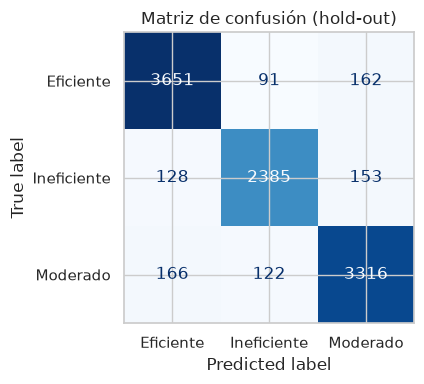

In [13]:
labels = sorted(y.unique())
cm = confusion_matrix(y_te, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión (hold-out)")
plt.tight_layout()
plt.show()


### 5.1 Importancia de features

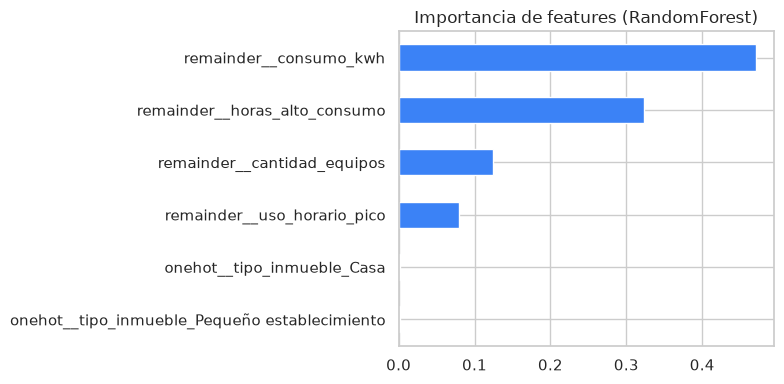

remainder__consumo_kwh                           0.470981
remainder__horas_alto_consumo                    0.322874
remainder__cantidad_equipos                      0.124461
remainder__uso_horario_pico                      0.079111
onehot__tipo_inmueble_Casa                       0.001315
onehot__tipo_inmueble_Pequeño establecimiento    0.001259
dtype: float64

In [14]:
feature_names_out = pipe.named_steps["preprocess"].get_feature_names_out()
importances = pipe.named_steps["model"].feature_importances_

fi = pd.Series(importances, index=feature_names_out).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
fi.plot(kind="barh", ax=ax, color="#3b82f6")
ax.set_title("Importancia de features (RandomForest)")
plt.tight_layout()
plt.show()

fi.sort_values(ascending=False)


**Lectura:** `consumo_kwh` domina la decisión del modelo, seguido de
`horas_alto_consumo` — coherente con el análisis exploratorio (sección 2.5) y con la
metodología documentada en `INFORME_HIBRIDO_v3.md`.


## 6. Modelo final (entrenado con todos los datos)

Una vez validada la metodología (secciones 4 y 5), el modelo que se sirve en producción
se reentrena con el 100% del dataset — más datos de entrenamiento, mismo pipeline.


In [15]:
final_pipe = build_pipeline()
final_pipe.fit(X, y)
print("Modelo final entrenado con", len(df), "filas.")


Modelo final entrenado con 50869 filas.


## 7. Generación de recomendaciones basadas en reglas

El motor de recomendaciones (implementado en producción en
`backend/src/main/java/com/energiai/service/AnalisisEnergeticoService.java`, según
`architecture/decisions/ADR-002-motor-recomendaciones-backend.md`) aplica 6 reglas de
negocio sobre la categoría predicha y las variables de entrada. Se reproduce aquí en
Python para documentar la lógica junto al análisis que la sustenta.

**Fuente de las reglas:** `reglas_recomendaciones.md` (Cristian Coronel, Data Analyst).


In [16]:
PESOS_SCORE = {"Eficiente": 100, "Moderado": 50, "Ineficiente": 0}
PESO_PRIORIDAD = {"Ineficiente": 1.0, "Moderado": 0.4, "Eficiente": 0.0}

def generar_recomendaciones(categoria, uso_horario_pico, horas_alto_consumo, consumo_kwh, tipo_inmueble):
    recs = []

    if categoria == "Ineficiente" and uso_horario_pico:
        recs.append("Tu consumo es elevado y se concentra en el horario de mayor precio de "
                     "la tarifa. Evita usar electrodomesticos de alto consumo en horas pico "
                     "(18:00-22:00).")

    if horas_alto_consumo > 6 and categoria != "Eficiente":
        recs.append("Tu perfil muestra varias horas de alto consumo durante el dia. Revisa "
                     "equipos que permanecen encendidos mas tiempo del necesario.")

    if consumo_kwh > 231 and categoria != "Eficiente":
        recs.append("Tu consumo mensual esta por encima de la mayoria de los usuarios. "
                     "Identifica los equipos que mas consumen y aprovecha modos de ahorro.")

    if categoria == "Moderado" and uso_horario_pico:
        recs.append("Tu consumo en general es moderado, pero sigues usando energia en horas "
                     "pico. Intenta mover tareas fuera de 18:00-22:00.")

    if categoria == "Eficiente" and uso_horario_pico:
        recs.append("Mantienes un perfil eficiente. Desplaza tareas a horario temprano o "
                     "nocturno para ahorrar aun mas.")

    if tipo_inmueble == "Pequeño establecimiento":
        recs.append("Como pequeno establecimiento, presta atencion al horario comercial pico "
                     "(16:00-20:00) y a los equipos de refrigeracion/exhibicion.")
    else:
        recs.append("En tu hogar, enfocate en iluminacion, refrigerador, lavadora y apagar "
                     "equipos cuando no esten en uso.")

    if not recs:
        recs.append("Tu consumo energetico es eficiente. Sigue con tus buenos habitos.")
    return recs


def score_eficiencia(proba_dict):
    return round(sum(PESOS_SCORE.get(c, 0) * p for c, p in proba_dict.items()), 2)


def prioridad(consumo_kwh, categoria):
    return round(consumo_kwh * PESO_PRIORIDAD.get(categoria, 0.0), 2)


### 7.1 Demostración con 4 perfiles reales

In [17]:
perfiles_demo = pd.DataFrame([
    {"consumo_kwh": 600, "cantidad_equipos": 18, "horas_alto_consumo": 10, "uso_horario_pico": True,  "tipo_inmueble": "Casa"},
    {"consumo_kwh": 190, "cantidad_equipos": 8,  "horas_alto_consumo": 4,  "uso_horario_pico": True,  "tipo_inmueble": "Casa"},
    {"consumo_kwh": 80,  "cantidad_equipos": 4,  "horas_alto_consumo": 2,  "uso_horario_pico": False, "tipo_inmueble": "Casa"},
    {"consumo_kwh": 400, "cantidad_equipos": 15, "horas_alto_consumo": 9,  "uso_horario_pico": False, "tipo_inmueble": "Pequeño establecimiento"},
])[FEATURES]

pred_cat = final_pipe.predict(perfiles_demo)
pred_proba = final_pipe.predict_proba(perfiles_demo)
clases = final_pipe.named_steps["model"].classes_

for i, row in perfiles_demo.iterrows():
    categoria = pred_cat[i]
    proba_dict = dict(zip(clases, pred_proba[i]))
    probabilidad = round(max(proba_dict.values()), 4)
    score = score_eficiencia(proba_dict)
    prio = prioridad(row["consumo_kwh"], categoria)
    recs = generar_recomendaciones(categoria, row["uso_horario_pico"], row["horas_alto_consumo"],
                                    row["consumo_kwh"], row["tipo_inmueble"])

    print(f"--- Perfil {i+1}: {row['consumo_kwh']} kWh, {row['tipo_inmueble']}, "
          f"pico={row['uso_horario_pico']} ---")
    print(f"  categoria={categoria} | probabilidad={probabilidad} | "
          f"score_eficiencia={score} | prioridad={prio}")
    for r in recs:
        print(f"  - {r}")
    print()


--- Perfil 1: 600 kWh, Casa, pico=True ---
  categoria=Ineficiente | probabilidad=0.94 | score_eficiencia=3.5 | prioridad=600.0
  - Tu consumo es elevado y se concentra en el horario de mayor precio de la tarifa. Evita usar electrodomesticos de alto consumo en horas pico (18:00-22:00).
  - Tu perfil muestra varias horas de alto consumo durante el dia. Revisa equipos que permanecen encendidos mas tiempo del necesario.
  - Tu consumo mensual esta por encima de la mayoria de los usuarios. Identifica los equipos que mas consumen y aprovecha modos de ahorro.
  - En tu hogar, enfocate en iluminacion, refrigerador, lavadora y apagar equipos cuando no esten en uso.

--- Perfil 2: 190 kWh, Casa, pico=True ---
  categoria=Moderado | probabilidad=0.495 | score_eficiencia=49.75 | prioridad=76.0
  - Tu consumo en general es moderado, pero sigues usando energia en horas pico. Intenta mover tareas fuera de 18:00-22:00.
  - En tu hogar, enfocate en iluminacion, refrigerador, lavadora y apagar equipos 

**Costo estimado y ahorro potencial** (tarifa de referencia $0.75/kWh, según el brief
oficial del hackathon):


In [18]:
TARIFA_KWH = 0.75

for i, row in perfiles_demo.iterrows():
    costo = round(row["consumo_kwh"] * TARIFA_KWH, 2)
    ahorro_conservador = round(costo * 0.03, 2)
    ahorro_medio = round(costo * 0.05, 2)
    ahorro_alto = round(costo * 0.08, 2)
    print(f"Perfil {i+1}: costo_estimado_mensual=${costo} | "
          f"ahorro potencial: conservador=${ahorro_conservador}, medio=${ahorro_medio}, alto=${ahorro_alto}")


Perfil 1: costo_estimado_mensual=$450.0 | ahorro potencial: conservador=$13.5, medio=$22.5, alto=$36.0
Perfil 2: costo_estimado_mensual=$142.5 | ahorro potencial: conservador=$4.27, medio=$7.12, alto=$11.4
Perfil 3: costo_estimado_mensual=$60.0 | ahorro potencial: conservador=$1.8, medio=$3.0, alto=$4.8
Perfil 4: costo_estimado_mensual=$300.0 | ahorro potencial: conservador=$9.0, medio=$15.0, alto=$24.0


## 8. Extra: detección de anomalías (IsolationForest)

Propuesta de Harrinson Villabona: un modelo no supervisado complementario al clasificador,
para marcar hogares con patrones de consumo estadísticamente atípicos frente a sus pares
— no necesariamente "Ineficiente", sino "inusual" (posible falla de equipo, error de
medición, o un caso genuinamente atípico que vale la pena revisar a mano).

Se documenta aquí como análisis exploratorio; no se despliega en producción en esta
iteración (decisión tomada para no arriesgar el redespliegue de la demo con un modelo
nuevo) — queda como evolución de Fase 2.


In [19]:
iso_features = df[NUMERIC_FEATURES + BOOL_FEATURES].copy()
iso_features["uso_horario_pico"] = iso_features["uso_horario_pico"].astype(int)

iso_forest = IsolationForest(n_estimators=200, contamination=0.03, random_state=RANDOM_STATE, n_jobs=-1)
anomaly_pred = iso_forest.fit_predict(iso_features)  # -1 = anomalía, 1 = normal

df_anom = df.copy()
df_anom["es_anomalia"] = anomaly_pred == -1

print(f"Anomalías detectadas: {df_anom['es_anomalia'].sum()} de {len(df_anom)} "
      f"({df_anom['es_anomalia'].mean():.1%})")
print("\nDistribución de categoria entre las anomalías:")
print(df_anom[df_anom["es_anomalia"]]["categoria"].value_counts())


Anomalías detectadas: 1527 de 50869 (3.0%)

Distribución de categoria entre las anomalías:
categoria
Ineficiente    1077
Moderado        307
Eficiente       143
Name: count, dtype: int64


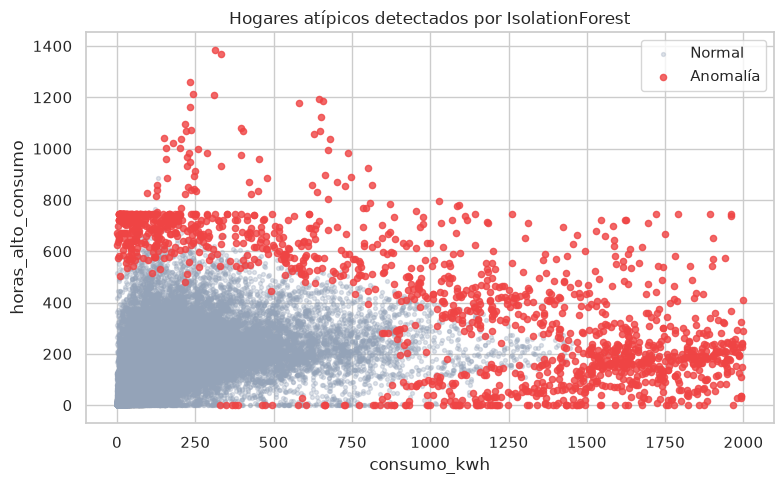

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
normal = df_anom[~df_anom["es_anomalia"]]
anomalo = df_anom[df_anom["es_anomalia"]]

ax.scatter(normal["consumo_kwh"], normal["horas_alto_consumo"], s=8, alpha=0.3,
           color="#94a3b8", label="Normal")
ax.scatter(anomalo["consumo_kwh"], anomalo["horas_alto_consumo"], s=20, alpha=0.8,
           color="#ef4444", label="Anomalía")
ax.set_xlabel("consumo_kwh")
ax.set_ylabel("horas_alto_consumo")
ax.set_title("Hogares atípicos detectados por IsolationForest")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Serialización del modelo entrenado

Se serializa el **pipeline completo** (preprocesamiento + modelo), no solo el estimador
— así el servicio de inferencia recibe features crudas y el mismo objeto las codifica
igual que en entrenamiento. Este es el mismo artefacto que produce `ml-service/train.py`
en el build de producción (`ml-service/Dockerfile`); aquí se documenta el mismo proceso
de forma reproducible y explicada.


In [21]:
MODELS_DIR = REPO_ROOT / "ml-service" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "model.pkl"

joblib.dump(final_pipe, MODEL_PATH, compress=3)
size_mb = MODEL_PATH.stat().st_size / (1024 * 1024)
print(f"Modelo serializado: {MODEL_PATH} ({size_mb:.1f} MB)")

# Nota: model.pkl esta en .gitignore a proposito (no se versiona en Git);
# se regenera en cada build de la imagen Docker via train.py. Ver
# architecture/03-Arquitectura-Empresarial-EnergiAI.md DA-05.


Modelo serializado: /root/EnergiAI-G9-Latam-Team15/ml-service/models/model.pkl (54.3 MB)


In [22]:
# Smoke test: recargar el .pkl y predecir (verificacion end-to-end del artefacto)
loaded = joblib.load(MODEL_PATH)
sample = pd.DataFrame([{
    "consumo_kwh": 350.0, "cantidad_equipos": 12, "horas_alto_consumo": 8,
    "uso_horario_pico": True, "tipo_inmueble": "Casa",
}])[FEATURES]

pred = loaded.predict(sample)[0]
proba = float(np.max(loaded.predict_proba(sample)))
print(f"Entrada: {sample.to_dict(orient='records')[0]}")
print(f"Prediccion recargada desde disco: categoria={pred!r} | probabilidad={proba:.2f}")


Entrada: {'consumo_kwh': 350.0, 'cantidad_equipos': 12, 'horas_alto_consumo': 8, 'uso_horario_pico': True, 'tipo_inmueble': 'Casa'}
Prediccion recargada desde disco: categoria='Ineficiente' | probabilidad=0.53


## 10. Conclusiones

- El modelo **RandomForest** alcanza **~92% de accuracy** (StratifiedKFold 5-fold) en la
  clasificación de eficiencia energética en 3 clases, muy por encima del baseline de
  clase mayoritaria (~38%).
- `consumo_kwh` y `horas_alto_consumo` son las variables más determinantes — consistente
  con el análisis exploratorio y con la intuición de dominio (el consumo total y su
  concentración temporal son los mejores predictores de eficiencia).
- El motor de recomendaciones (6 reglas de negocio) y el score continuo de eficiencia
  (0-100) complementan la clasificación categórica con información más granular, y ya
  están implementados en producción (ver `AnalisisEnergeticoService.java`).
- La detección de anomalías con IsolationForest se documenta como línea de trabajo futura,
  para identificar patrones de consumo atípicos sin necesidad de reentrenar el modelo
  supervisado.
- El pipeline completo se serializa y se verifica con un smoke test end-to-end antes de
  darse por válido para servir en producción.

**Repositorio:** https://github.com/No-Country-simulation/EnergiAI-G9-Latam-Team15
